<a href="https://colab.research.google.com/github/b181005/Cellpose-Image-Analysis/blob/main/260323_cellposeAll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install cellpose matplotlib numpy imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.1/213.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.1 MB/s eta 0:00:00


In [ ]:
 #single image plot test
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

creating new log file
2026-03-20 18:53:38,066 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 18:53:38,067 [INFO] 
cellpose version: 	4.0.9 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-20 18:53:38,470 [INFO] ** TORCH CUDA version installed and working. **


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
!ls /content/drive/MyDrive/DATA/

Mounted at /content/drive
ls: cannot access '/content/drive/MyDrive/DATA/': No such file or directory


In [ ]:
# Loop through folders and find images
dir_path = "//content/drive/MyDrive/cellpose_data/Psychatg02_07112025/"
dir_obj = Path(dir_path)

base = Path("/content/drive/MyDrive/cellpose_data/Psychatg02_07112025")

if not dir_obj.exists():
    raise FileNotFoundError(f"Directory not found: {dir_path}")

# 2. List the files
image_ext = ".tif"
all_files = list(dir_obj.rglob("*" + image_ext))
files = natsorted([f for f in all_files if "_masks" not in f.name and "_flows" not in f.name])

# 3. Check if files were found
if len(files) == 0:
    raise FileNotFoundError(f"No {image_ext} files found in {dir_path}")
else:
    print(f"{len(files)} images found.")
    print(f"Success! Found {len(files)} total images across all subfolders.")
    # Show the first 3 paths to verify they are correct
    for f in files[:3]:
        print(f"Found: {f}")

90 images found.
Success! Found 90 total images across all subfolders.
Found: //content/drive/MyDrive/cellpose_data/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH2.tif
Found: //content/drive/MyDrive/cellpose_data/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH4.tif
Found: //content/drive/MyDrive/cellpose_data/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_Overlay.tif


In [ ]:
# 1. Define your base path and conditions
study_map = {
    "Control": "B+_w1",
    "Condition": "S+B+_w1"
}

# 2. Initialize a dictionary to hold the separated file paths
separated_files = {key: [] for key in study_map.keys()}

# 3. Loop through the folders and sort files
# We use rglob to find all .tif files recursively
for file_path in dir_obj.rglob("*.tif"):
    # Skip masks or flows if they exist to avoid duplicates
    if "_masks" in file_path.name or "_flows" in file_path.name:
        continue

    # Check which condition folder the file belongs to
    for label, folder_keyword in study_map.items():
        if folder_keyword in str(file_path):
            separated_files[label].append(file_path)

# 4. Verify the results
for label, files in separated_files.items():
    print(f"{label}: found {len(files)} images.")
    if files:
        print(f"   Example: {files[0].name}")

Control: found 36 images.
   Example: HM_W001_P00006_CH4.tif
Condition: found 18 images.
   Example: HM_W001_P00006_CH2.tif


In [ ]:

# INITIALIZATION (MUST BE RUN BEFORE THE FUNCTION IS CALLED)

# Load model (if not already)
model = models.CellposeModel(gpu=True)
rows = []
primary_id = 1

def run_cell_analysis(ch2_path):
    """
    Performs Cellpose segmentation and feature extraction for a single image pair.
    The data is appended to the global 'rows' list.
    """
    print(f"\n--- Analyzing file: {os.path.basename(ch2_path)} ---")

    global rows
    rows = []
    global primary_id
    primary_id = 1

    # Assume ch2_path is the full path string (e.g., '.../HM_W001_P00001_CH2.tif')
    p = Path(ch2_path)
    ch4_path = p.with_name(p.name.replace("_CH2.tif", "_CH4.tif"))

    # 1. Load Images (as 2D grayscale)
    # Removed as_gray=True as it's not a valid argument for io.imread
    ch1_img = io.imread(ch2_path)
    ch4_img = io.imread(ch4_path)

    # 2. Run Cellpose (on the ch1/GFP channel)
    masks, flows, styles = model.eval([ch1_img],
                                      diameter=30,
                                      flow_threshold=0.4,
                                      cellprob_threshold=0.0)
    masks = masks[0]  # Unpack from list

    # 3. Measure Properties for BOTH channels using the SAME masks
    # The redundant [:, :] slicing is removed for cleaner code.
    props = regionprops(masks, intensity_image=ch1_img)
    ch4_props = regionprops(masks, intensity_image=ch4_img)

    # Get File Name (for tracking)
    file_name = os.path.splitext(os.path.basename(ch2_path))[0]

    # 4. COMBINE DATA INTO ONE ROW PER CELL (The main fix)
    # The 'props' and 'ch4_props' lists are guaranteed to be in the same order
    # and correspond to the same labels, so we use zip().
    for p_gfp, p_s647 in zip(props, ch4_props):
        rows.append({
            "file": file_name,
            "primary_id": primary_id,
            "cell_id": p_gfp.label,
            "area_px": p_gfp.area,
            "mean_gfp": p_gfp.mean_intensity,
            "mean_s647": p_s647.mean_intensity # Both intensities are now in one row
        })

    # Save mask
    #mask_path = save_folder / f"{all_files[i].stem}_mask.tif"
    mask_path = base / "masks_cp.tif"
    io.imsave(mask_path, masks[0])

    primary_id += 1

2026-03-20 19:01:55,441 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 19:01:55,442 [INFO] >>>> using GPU (CUDA)
2026-03-20 19:01:57,435 [INFO] >>>> loading model /root/.cellpose/models/cpsam


In [ ]:
# --- Execute the function for both channels ---
# 1. Run analysis for CH2
# CH_basepath = "C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/"
# ch2_path = os.path.join(CH_basepath, filename + "_CH2.tif")
# CH2 = img
# CH4 = "/content/drive/MyDrive/cellpose_data/Psychatg02_07112025/S+B+_w1/W001/P00001/HM_W001_P00001_CH4.tif"

# run_cell_analysis(CH2)
# df_Splus = pd.DataFrame(rows)

# CH2 = img2
# CH4 = "/content/drive/MyDrive/cellpose_data/Psychatg02_07112025/B+_w1/W001/P00001/HM_W001_P00001_CH4.tif"
# run_cell_analysis(CH2)
# df_Sminus = pd.DataFrame(rows)
# df_all = pd.DataFrame(rows)

# print(f"df_Splus now has {len(df_Splus)} rows.")
# print(f"df_Sminus now has {len(df_Sminus)} rows.")

In [ ]:
# --- Execute the function for all images in each condition ---

# 1. Process "Condition" (S+B+)
rows = [] # Reset rows before starting
for ch2_path in separated_files["Condition"]:
    # We only want to run the analysis on CH2 files
    if "_CH2.tif" in ch2_path.name:
        run_cell_analysis(str(ch2_path))

df_Splus = pd.DataFrame(rows)

# 2. Process "Control" (B+)
rows = [] # Reset rows for the next group
for ch2_path in separated_files["Control"]:
    # We only want to run the analysis on CH2 files
    if "_CH2.tif" in ch2_path.name:
        run_cell_analysis(str(ch2_path))

df_Sminus = pd.DataFrame(rows)

print(f"df_Splus (Condition) now has {len(df_Splus)} rows.")
print(f"df_Sminus (Control) now has {len(df_Sminus)} rows.")


--- Analyzing file: HM_W001_P00006_CH2.tif ---

--- Analyzing file: HM_W001_P00001_CH2.tif ---

--- Analyzing file: HM_W001_P00003_CH2.tif ---

--- Analyzing file: HM_W001_P00004_CH2.tif ---

--- Analyzing file: HM_W001_P00005_CH2.tif ---

--- Analyzing file: HM_W001_P00002_CH2.tif ---

--- Analyzing file: HM_W001_P00006_CH2.tif ---

--- Analyzing file: HM_W001_P00002_CH2.tif ---

--- Analyzing file: HM_W001_P00001_CH2.tif ---

--- Analyzing file: HM_W001_P00003_CH2.tif ---

--- Analyzing file: HM_W001_P00005_CH2.tif ---

--- Analyzing file: HM_W001_P00004_CH2.tif ---

--- Analyzing file: HM_W001_P00006_CH2.tif ---

--- Analyzing file: HM_W001_P00001_CH2.tif ---

--- Analyzing file: HM_W001_P00003_CH2.tif ---

--- Analyzing file: HM_W001_P00004_CH2.tif ---

--- Analyzing file: HM_W001_P00005_CH2.tif ---

--- Analyzing file: HM_W001_P00002_CH2.tif ---
df_Splus (Condition) now has 180 rows.
df_Sminus (Control) now has 180 rows.


In [ ]:
# Tina delete later#
# --- Execute the function for both channels ---
# 1. Run analysis for CH2
# CH_basepath = "C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/S+B+_w1/"

# all_filenames = ["FOV1","FOV2","FOV3"];
# df=[];
# for z=1:len(all_filenames)
#     rows = []
#     primary_id = 1
#     run_cell_analysis(strcat(CH_basepath+all_filenames(z)+"_CH2.tif"), strcat(CH_basepath+all_filenames(z)+"_CH4.tif");
#     df = [df; pd.DataFrame(rows)]
# end



In [ ]:
df = pd.DataFrame(rows)
df

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647
0,HM_W001_P00002_CH2,1,1,94.0,"[0.0, 24.638297872340427, 0.0]","[15.393617021276595, 0.0, 15.393617021276595]"
1,HM_W001_P00002_CH2,1,2,113.0,"[0.0, 29.442477876106196, 0.0]","[15.893805309734514, 0.0, 15.893805309734514]"
2,HM_W001_P00002_CH2,1,3,53.0,"[0.0, 31.30188679245283, 0.0]","[19.77358490566038, 0.0, 19.77358490566038]"
3,HM_W001_P00002_CH2,1,4,37.0,"[0.0, 30.243243243243242, 0.0]","[10.243243243243244, 0.0, 10.243243243243244]"
4,HM_W001_P00002_CH2,1,5,95.0,"[0.0, 17.778947368421054, 0.0]","[6.3578947368421055, 0.0, 6.3578947368421055]"
...,...,...,...,...,...,...
175,HM_W001_P00002_CH2,1,176,81.0,"[0.0, 37.135802469135804, 0.0]","[12.209876543209877, 0.0, 12.209876543209877]"
176,HM_W001_P00002_CH2,1,177,113.0,"[0.0, 28.123893805309734, 0.0]","[19.1858407079646, 0.0, 19.1858407079646]"
177,HM_W001_P00002_CH2,1,178,53.0,"[0.0, 43.81132075471698, 0.0]","[10.849056603773585, 0.0, 10.849056603773585]"
178,HM_W001_P00002_CH2,1,179,82.0,"[0.0, 63.02439024390244, 0.0]","[15.109756097560975, 0.0, 15.109756097560975]"


In [ ]:
df_Splus

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647
0,HM_W001_P00002_CH2,1,1,94.0,"[0.0, 24.638297872340427, 0.0]","[15.393617021276595, 0.0, 15.393617021276595]"
1,HM_W001_P00002_CH2,1,2,113.0,"[0.0, 29.442477876106196, 0.0]","[15.893805309734514, 0.0, 15.893805309734514]"
2,HM_W001_P00002_CH2,1,3,53.0,"[0.0, 31.30188679245283, 0.0]","[19.77358490566038, 0.0, 19.77358490566038]"
3,HM_W001_P00002_CH2,1,4,37.0,"[0.0, 30.243243243243242, 0.0]","[10.243243243243244, 0.0, 10.243243243243244]"
4,HM_W001_P00002_CH2,1,5,95.0,"[0.0, 17.778947368421054, 0.0]","[6.3578947368421055, 0.0, 6.3578947368421055]"
...,...,...,...,...,...,...
175,HM_W001_P00002_CH2,1,176,81.0,"[0.0, 37.135802469135804, 0.0]","[12.209876543209877, 0.0, 12.209876543209877]"
176,HM_W001_P00002_CH2,1,177,113.0,"[0.0, 28.123893805309734, 0.0]","[19.1858407079646, 0.0, 19.1858407079646]"
177,HM_W001_P00002_CH2,1,178,53.0,"[0.0, 43.81132075471698, 0.0]","[10.849056603773585, 0.0, 10.849056603773585]"
178,HM_W001_P00002_CH2,1,179,82.0,"[0.0, 63.02439024390244, 0.0]","[15.109756097560975, 0.0, 15.109756097560975]"


In [ ]:
df_Sminus

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647
0,HM_W001_P00002_CH2,1,1,94.0,"[0.0, 24.638297872340427, 0.0]","[15.393617021276595, 0.0, 15.393617021276595]"
1,HM_W001_P00002_CH2,1,2,113.0,"[0.0, 29.442477876106196, 0.0]","[15.893805309734514, 0.0, 15.893805309734514]"
2,HM_W001_P00002_CH2,1,3,53.0,"[0.0, 31.30188679245283, 0.0]","[19.77358490566038, 0.0, 19.77358490566038]"
3,HM_W001_P00002_CH2,1,4,37.0,"[0.0, 30.243243243243242, 0.0]","[10.243243243243244, 0.0, 10.243243243243244]"
4,HM_W001_P00002_CH2,1,5,95.0,"[0.0, 17.778947368421054, 0.0]","[6.3578947368421055, 0.0, 6.3578947368421055]"
...,...,...,...,...,...,...
175,HM_W001_P00002_CH2,1,176,81.0,"[0.0, 37.135802469135804, 0.0]","[12.209876543209877, 0.0, 12.209876543209877]"
176,HM_W001_P00002_CH2,1,177,113.0,"[0.0, 28.123893805309734, 0.0]","[19.1858407079646, 0.0, 19.1858407079646]"
177,HM_W001_P00002_CH2,1,178,53.0,"[0.0, 43.81132075471698, 0.0]","[10.849056603773585, 0.0, 10.849056603773585]"
178,HM_W001_P00002_CH2,1,179,82.0,"[0.0, 63.02439024390244, 0.0]","[15.109756097560975, 0.0, 15.109756097560975]"


In [ ]:
#concat the S+ and S-
df_Splus['Condition'] = 'S+B+'
df_Sminus['Condition'] = 'S-B+'

# Combine the two DataFrames
df_combined = pd.concat([df_Splus, df_Sminus], ignore_index=True)

# Extract the scalar mean intensity from the arrays before calculating the ratio
df_combined['mean_gfp_scalar'] = df_combined['mean_gfp'].apply(lambda x: x[1] if isinstance(x, np.ndarray) and len(x) > 1 else x)
df_combined['mean_s647_scalar'] = df_combined['mean_s647'].apply(lambda x: x[1] if isinstance(x, np.ndarray) and len(x) > 1 else x)

df_combined['ratio_s647_gfp'] = df_combined['mean_s647_scalar'] / (df_combined['mean_gfp_scalar'] + 1e-9)

<Axes: xlabel='Condition', ylabel='ratio_s647_gfp'>

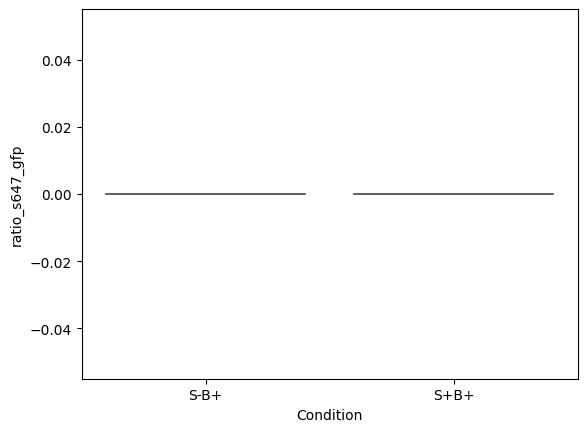

In [ ]:
#violin plot
sns.violinplot(
    data=df_combined,
    x='Condition',
    y='ratio_s647_gfp',
    hue='Condition',  # ADDED: Assign x to hue as recommended
    legend=False,     # ADDED: Hide the redundant legend
    palette=['blue', 'gray'],
    order=['S-B+', 'S+B+']
)

In [ ]:
df_combined

,file,primary_id,cell_id,area_px,mean_gfp,mean_s647,Condition,mean_gfp_scalar,mean_s647_scalar,ratio_s647_gfp
0,HM_W001_P00002_CH2,1,1,94.0,"[0.0, 24.638297872340427, 0.0]","[15.393617021276595, 0.0, 15.393617021276595]",S+B+,24.638298,0.0,0.0
1,HM_W001_P00002_CH2,1,2,113.0,"[0.0, 29.442477876106196, 0.0]","[15.893805309734514, 0.0, 15.893805309734514]",S+B+,29.442478,0.0,0.0
2,HM_W001_P00002_CH2,1,3,53.0,"[0.0, 31.30188679245283, 0.0]","[19.77358490566038, 0.0, 19.77358490566038]",S+B+,31.301887,0.0,0.0
3,HM_W001_P00002_CH2,1,4,37.0,"[0.0, 30.243243243243242, 0.0]","[10.243243243243244, 0.0, 10.243243243243244]",S+B+,30.243243,0.0,0.0
4,HM_W001_P00002_CH2,1,5,95.0,"[0.0, 17.778947368421054, 0.0]","[6.3578947368421055, 0.0, 6.3578947368421055]",S+B+,17.778947,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
355,HM_W001_P00002_CH2,1,176,81.0,"[0.0, 37.135802469135804, 0.0]","[12.209876543209877, 0.0, 12.209876543209877]",S-B+,37.135802,0.0,0.0
356,HM_W001_P00002_CH2,1,177,113.0,"[0.0, 28.123893805309734, 0.0]","[19.1858407079646, 0.0, 19.1858407079646]",S-B+,28.123894,0.0,0.0
357,HM_W001_P00002_CH2,1,178,53.0,"[0.0, 43.81132075471698, 0.0]","[10.849056603773585, 0.0, 10.849056603773585]",S-B+,43.811321,0.0,0.0
358,HM_W001_P00002_CH2,1,179,82.0,"[0.0, 63.02439024390244, 0.0]","[15.109756097560975, 0.0, 15.109756097560975]",S-B+,63.024390,0.0,0.0


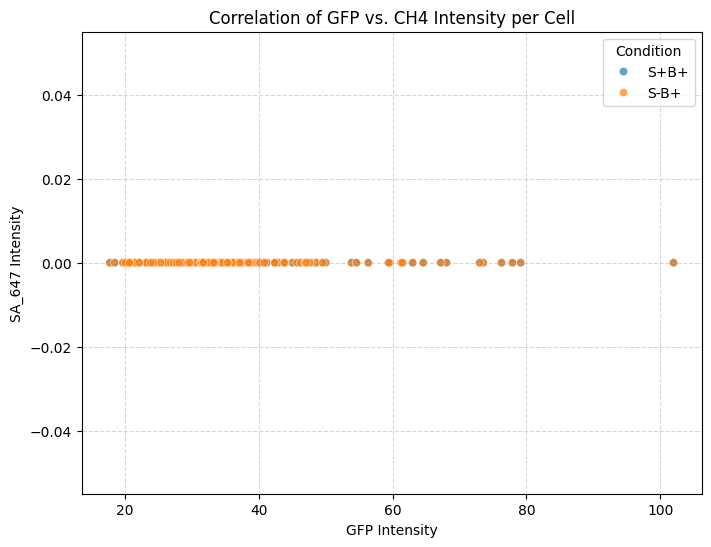

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_combined,
    x='mean_gfp_scalar',
    y='mean_s647_scalar',
    hue='Condition',  # Use the new column to distinguish colors
    alpha=0.7         # Set transparency for better visibility of overlapping points
)

plt.xlabel("GFP Intensity")
plt.ylabel("SA_647 Intensity")
plt.title("Correlation of GFP vs. CH4 Intensity per Cell")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, ch1_img, masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.savefig("figure.svg")   # SVG vector
plt.savefig("figure.pdf")   # PDF vector
plt.savefig("figure.eps")   # EPS vector


In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Drop non-numeric columns automatically
numeric_df = df.select_dtypes(include=['number'])

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(numeric_df)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=40)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Cell Features")
plt.tight_layout()
plt.show()
